# Simulate Degraded Galaxy Observations

This notebook implements the computational-imaging forward model for the project. The processed images from notebook 02 are treated as clean ground truth `x`; this notebook creates degraded observations `y` by applying blur, lower-resolution sampling, and noise.

A simple model for this stage is:

```text
y = D(B(x)) + n
```

where `B` is optical blur, `D` is detector/resolution loss, and `n` is sensor noise. The next pipeline step will be reconstructing `x` from `y`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from galaxy_zoo_project.degradation import (
    DegradationConfig,
    build_degraded_dataset,
    degrade_array,
    image_quality_metrics,
    load_rgb_float,
)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "galaxy_zoo_128"
PROCESSED_MANIFEST_PATH = PROCESSED_DIR / "manifest.csv"
DEGRADED_DIR = PROJECT_ROOT / "data" / "degraded" / "galaxy_zoo_128_moderate"

PROJECT_ROOT, PROCESSED_MANIFEST_PATH, DEGRADED_DIR


/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project'),
 PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/processed/galaxy_zoo_128/manifest.csv'),
 PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/degraded/galaxy_zoo_128_moderate'))

## Configure the Forward Model

The default degradation is intentionally moderate: visible blur/noise, but still enough structure that reconstruction has something meaningful to recover.


In [2]:
DEGRADATION_LIMIT = 64  # Set to None after the settings look good.
BLUR_SIGMA = 1.2
DOWNSAMPLE_FACTOR = 2
GAUSSIAN_NOISE_STD = 0.03
POISSON_PEAK = None
OVERWRITE = True
SEED = 42

config = DegradationConfig(
    project_root=PROJECT_ROOT,
    processed_manifest_path=PROCESSED_MANIFEST_PATH,
    output_dir=DEGRADED_DIR,
    blur_sigma=BLUR_SIGMA,
    downsample_factor=DOWNSAMPLE_FACTOR,
    gaussian_noise_std=GAUSSIAN_NOISE_STD,
    poisson_peak=POISSON_PEAK,
    limit=DEGRADATION_LIMIT,
    seed=SEED,
    overwrite=OVERWRITE,
)

config


DegradationConfig(project_root=PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project'), processed_manifest_path=PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/processed/galaxy_zoo_128/manifest.csv'), output_dir=PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/degraded/galaxy_zoo_128_moderate'), blur_sigma=1.2, downsample_factor=2, gaussian_noise_std=0.03, poisson_peak=None, limit=64, split=None, seed=42, overwrite=True)

## Generate Degraded Images

This writes degraded images and a manifest with PSNR/SSIM metrics. Existing images are reused unless `OVERWRITE = True`.


In [3]:
degraded_manifest = build_degraded_dataset(config)

print(f"Degraded images: {len(degraded_manifest):,}")
print(f"Manifest: {(DEGRADED_DIR / 'manifest.csv').relative_to(PROJECT_ROOT)}")
print(f"Images: {(DEGRADED_DIR / 'images').relative_to(PROJECT_ROOT)}")


Degrading images:   0%|          | 0/64 [00:00<?, ?image/s]

Degrading images:  14%|█▍        | 9/64 [00:00<00:00, 84.20image/s]

Degrading images:  28%|██▊       | 18/64 [00:00<00:00, 86.49image/s]

Degrading images:  42%|████▏     | 27/64 [00:00<00:00, 85.63image/s]

Degrading images:  56%|█████▋    | 36/64 [00:00<00:00, 86.34image/s]

Degrading images:  70%|███████   | 45/64 [00:00<00:00, 86.11image/s]

Degrading images:  84%|████████▍ | 54/64 [00:00<00:00, 83.99image/s]

Degrading images:  98%|█████████▊| 63/64 [00:00<00:00, 84.67image/s]

Degrading images: 100%|██████████| 64/64 [00:00<00:00, 85.08image/s]

Degraded images: 64
Manifest: data/degraded/galaxy_zoo_128_moderate/manifest.csv
Images: data/degraded/galaxy_zoo_128_moderate/images


## Inspect Degradation Metrics

PSNR and SSIM summarize how far the simulated observation moved away from the clean image. They are imperfect, but useful for comparing degradation settings.


In [4]:
degraded_manifest = pd.read_csv(DEGRADED_DIR / "manifest.csv")

print(degraded_manifest.shape)
display(degraded_manifest.head())
display(degraded_manifest[["psnr", "ssim"]].describe())


(64, 10)


,GalaxyID,clean_path,degraded_path,split,blur_sigma,downsample_factor,gaussian_noise_std,poisson_peak,psnr,ssim
0,100008,data/processed/galaxy_zoo_128/images/100008.jpg,data/degraded/galaxy_zoo_128_moderate/images/1...,train,1.2,2,0.03,NaN,30.580549,0.594665
1,100023,data/processed/galaxy_zoo_128/images/100023.jpg,data/degraded/galaxy_zoo_128_moderate/images/1...,train,1.2,2,0.03,NaN,31.319963,0.639357
2,100053,data/processed/galaxy_zoo_128/images/100053.jpg,data/degraded/galaxy_zoo_128_moderate/images/1...,train,1.2,2,0.03,NaN,30.442340,0.631712
3,100078,data/processed/galaxy_zoo_128/images/100078.jpg,data/degraded/galaxy_zoo_128_moderate/images/1...,train,1.2,2,0.03,NaN,30.587909,0.583836
4,100090,data/processed/galaxy_zoo_128/images/100090.jpg,data/degraded/galaxy_zoo_128_moderate/images/1...,train,1.2,2,0.03,NaN,30.258586,0.591410


,psnr,ssim
count,64.000000,64.000000
mean,30.617766,0.596228
std,0.614727,0.025425
min,29.288372,0.530988
25%,30.264634,0.581246
50%,30.695883,0.594450
75%,31.019993,0.613999
max,31.723115,0.661416


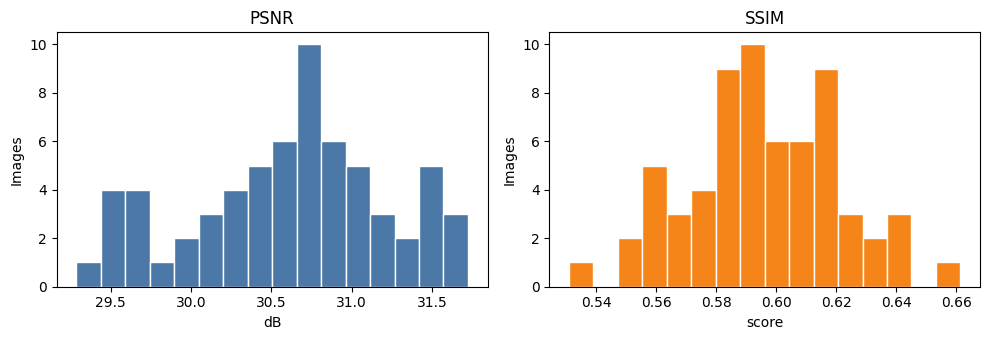

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(degraded_manifest["psnr"], bins=16, color="#4C78A8", edgecolor="white")
axes[0].set_title("PSNR")
axes[0].set_xlabel("dB")
axes[0].set_ylabel("Images")

axes[1].hist(degraded_manifest["ssim"], bins=16, color="#F58518", edgecolor="white")
axes[1].set_title("SSIM")
axes[1].set_xlabel("score")
axes[1].set_ylabel("Images")

plt.tight_layout()


## Preview Clean vs Degraded

The residual panel is amplified so the differences are visible. Bright residual structure means the degradation is removing morphology-relevant detail.


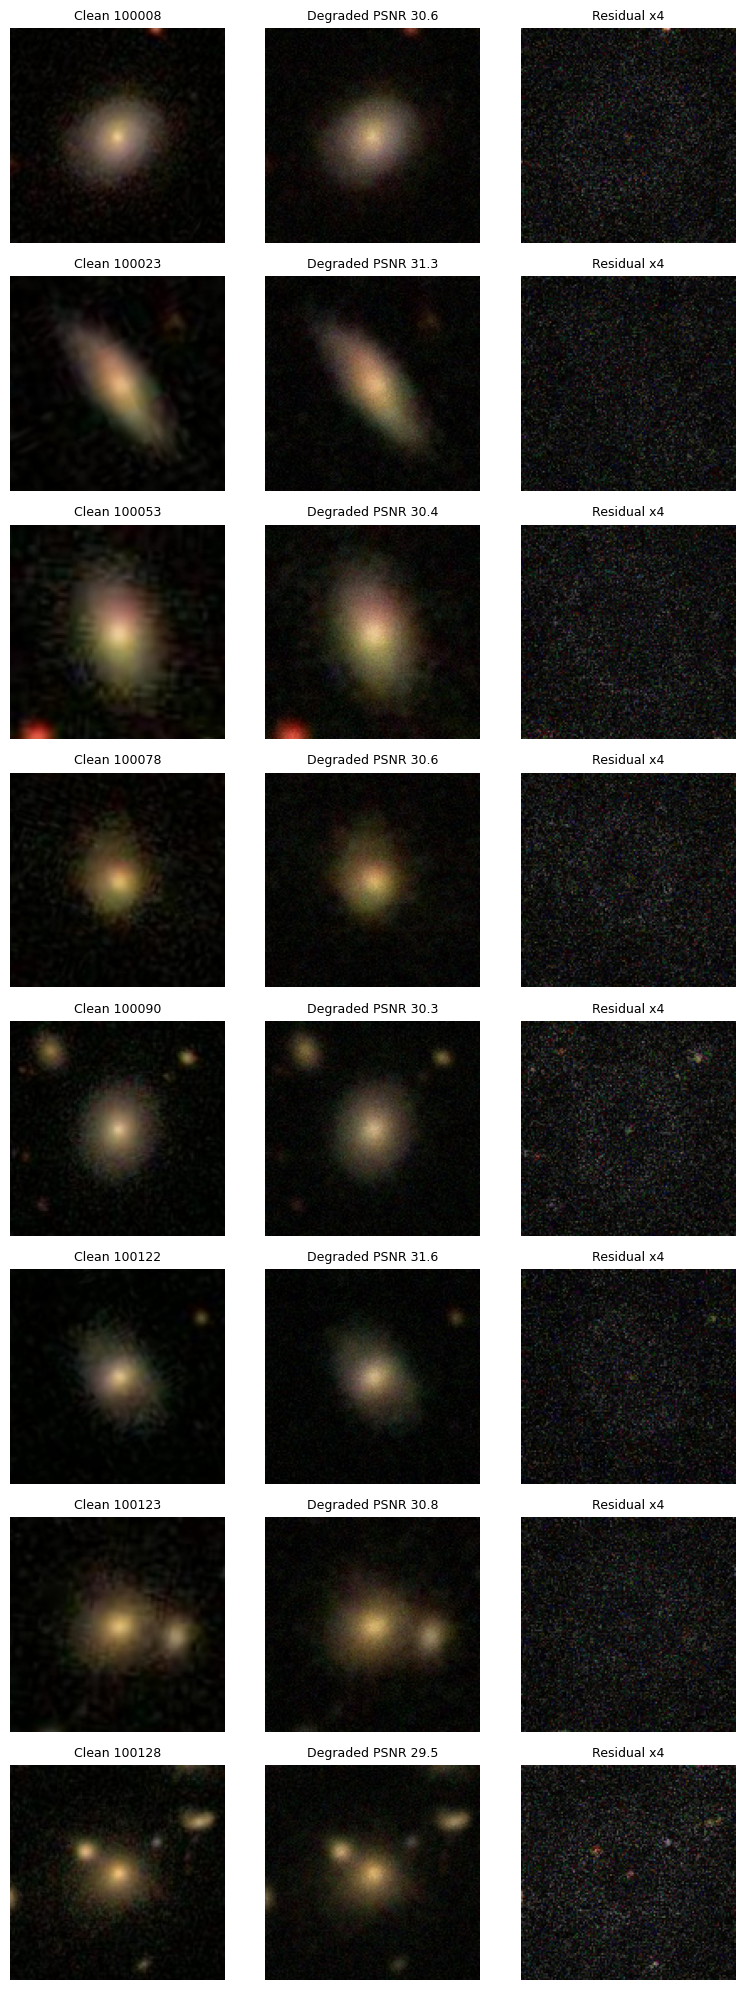

In [6]:
sample = degraded_manifest.head(8)
fig, axes = plt.subplots(len(sample), 3, figsize=(8, 2.5 * len(sample)))

for row_index, (_, row) in enumerate(sample.iterrows()):
    clean = load_rgb_float(PROJECT_ROOT / row["clean_path"])
    degraded = load_rgb_float(PROJECT_ROOT / row["degraded_path"])
    residual = np.abs(clean - degraded)
    residual = np.clip(residual * 4.0, 0.0, 1.0)

    axes[row_index, 0].imshow(clean)
    axes[row_index, 0].set_title(f"Clean {row['GalaxyID']}", fontsize=9)
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(degraded)
    axes[row_index, 1].set_title(f"Degraded PSNR {row['psnr']:.1f}", fontsize=9)
    axes[row_index, 1].axis("off")

    axes[row_index, 2].imshow(residual)
    axes[row_index, 2].set_title("Residual x4", fontsize=9)
    axes[row_index, 2].axis("off")

plt.tight_layout()


## Compare Degradation Severity

This small parameter sweep helps choose a degradation level before generating a larger dataset. The moderate setting above is a practical starting point for baseline reconstruction.


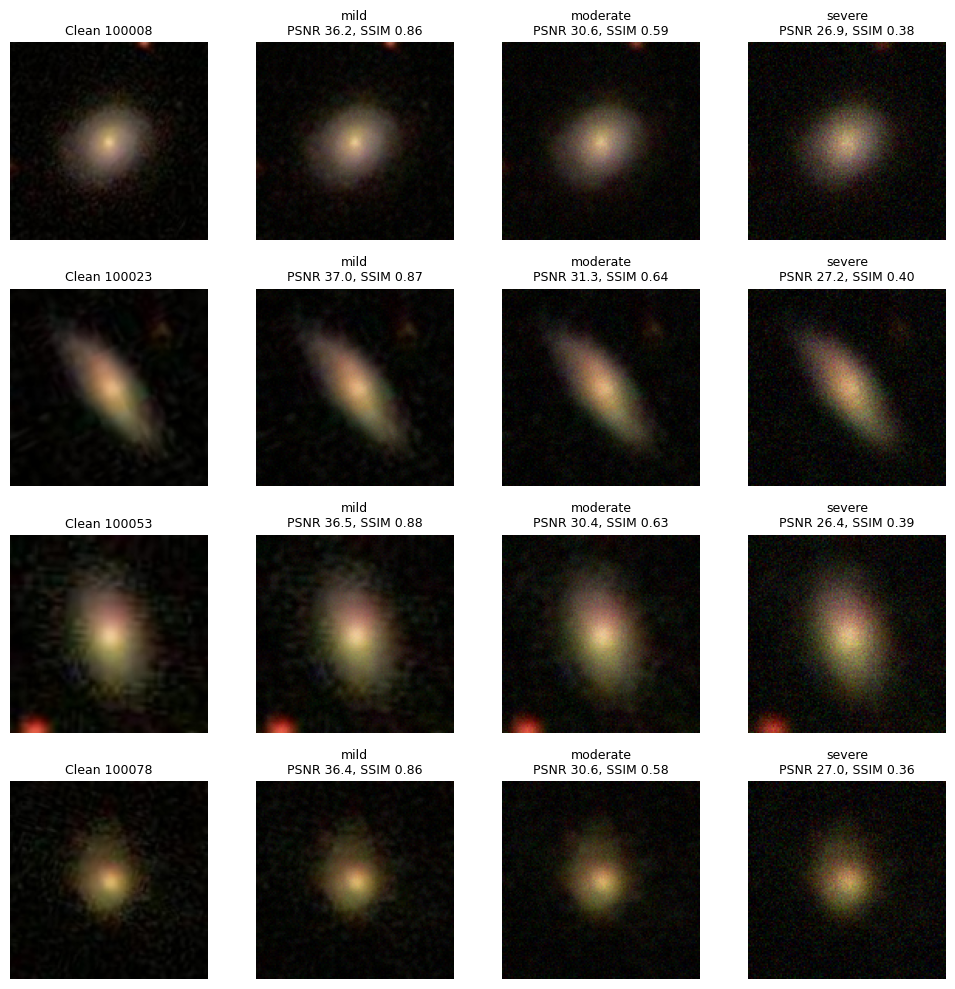

In [7]:
severity_settings = {
    "mild": {"blur_sigma": 0.7, "downsample_factor": 1, "gaussian_noise_std": 0.015, "poisson_peak": None},
    "moderate": {"blur_sigma": 1.2, "downsample_factor": 2, "gaussian_noise_std": 0.03, "poisson_peak": None},
    "severe": {"blur_sigma": 2.0, "downsample_factor": 4, "gaussian_noise_std": 0.05, "poisson_peak": None},
}

comparison_rows = []
comparison_sample = pd.read_csv(PROCESSED_MANIFEST_PATH).head(4)

fig, axes = plt.subplots(len(comparison_sample), len(severity_settings) + 1, figsize=(10, 2.5 * len(comparison_sample)))

for row_index, (_, row) in enumerate(comparison_sample.iterrows()):
    clean = load_rgb_float(PROJECT_ROOT / row["processed_path"])

    axes[row_index, 0].imshow(clean)
    axes[row_index, 0].set_title(f"Clean {row['GalaxyID']}", fontsize=9)
    axes[row_index, 0].axis("off")

    for col_index, (name, params) in enumerate(severity_settings.items(), start=1):
        rng = np.random.default_rng(SEED + int(row["GalaxyID"]))
        degraded = degrade_array(clean, rng=rng, **params)
        metrics = image_quality_metrics(clean, degraded)
        comparison_rows.append({"GalaxyID": row["GalaxyID"], "setting": name, **params, **metrics})

        axes[row_index, col_index].imshow(degraded)
        axes[row_index, col_index].set_title(f"{name}\nPSNR {metrics['psnr']:.1f}, SSIM {metrics['ssim']:.2f}", fontsize=9)
        axes[row_index, col_index].axis("off")

plt.tight_layout()
comparison = pd.DataFrame(comparison_rows)


In [8]:
display(
    comparison
    .groupby("setting")[["psnr", "ssim"]]
    .mean()
    .loc[["mild", "moderate", "severe"]]
)


,psnr,ssim
setting,,
mild,36.528118,0.868839
moderate,30.732690,0.612393
severe,26.873843,0.382128


## Output Summary

The degraded dataset is now ready for the reconstruction stage. The next notebook can compare classical baselines such as bicubic smoothing/denoising, Wiener-style filtering, or Richardson-Lucy deconvolution against these observations.


In [9]:
summary_path = DEGRADED_DIR / "summary.json"
print(summary_path.read_text())


{
  "config": {
    "project_root": "/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project",
    "processed_manifest_path": "/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/processed/galaxy_zoo_128/manifest.csv",
    "output_dir": "/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/degraded/galaxy_zoo_128_moderate",
    "blur_sigma": 1.2,
    "downsample_factor": 2,
    "gaussian_noise_std": 0.03,
    "poisson_peak": null,
    "limit": 64,
    "split": null,
    "seed": 42,
    "overwrite": true
  },
  "num_degraded_images": 64,
  "manifest_path": "data/degraded/galaxy_zoo_128_moderate/manifest.csv",
  "mean_psnr": 30.617765653618928,
  "mean_ssim": 0.5962275695055723
}

